# Mock Data Vector with Optical Selection Effects

Forward model for the Buzzard-like DES Y3 cluster mock including:

1. Intrinsic mass–richness relation from Costanzi et al. 2026, Eq. 15
   (DES-Y1 NC+3x2pt best fit).
2. Projection of $\lambda_\mathrm{true}\to\lambda_\mathrm{obs}$ via the
   Costanzi $P(\lambda_\mathrm{obs}|\lambda_\mathrm{true}, z)$ mixture
   (delta + positive exponential).
3. Per-halo $B_\mathrm{sel}$ weight (one-halo / small-scale limit, App. C).

Outputs:

- $N(\lambda_\mathrm{obs}, z)$ binned number counts.
- $\gamma_\mathrm{obs}(R, \lambda_\mathrm{obs}\text{-bin}, z\text{-bin}) = \text{stack}(B_\mathrm{sel}\,\gamma_\mathrm{mock})$.

Boost-factor contamination is not yet included.

In [32]:
import os
import fitsio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
from scipy.special import erfc
from astropy.table import Table, join
from astropy.cosmology import FlatLambdaCDM

from fileLoc import FileLocs
import radial_bins_phys_mpc as rbp

matplotlib.rc('xtick', labelsize=16, top=True, direction='in')
matplotlib.rc('ytick', labelsize=16, right=True, direction='in')
matplotlib.rc('axes', linewidth=1, labelsize=16)

## 1. Inputs

Everything the user can tune lives here.

In [33]:
# --- Cosmology --------------------------------------------------------
cosmo0 = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)

# --- Mass-richness / HOD parameters (Costanzi Eq. 15, DES-Y1 best fit).
# These are hard-coded inside costanzi_selection.py.
from costanzi_selection import (
    M_MIN, ALPHA, M_1, M_PIVOT, SIGM_INTR, EPSI, PIVOT_Z0,
    l_sat, l_tr, sig_intr, pltr_M,
    sample_lambda_true, sample_lambda_obs, projection_params,
    b_sel_one_halo,
    load_prj_interpolators, load_prj_posterior_mean,
)
print('DES-Y1 params: log10 M_min=%.4f  alpha=%.4f  log10 M_1=%.4f  sig_intr=%.4f  eps=%.4f  z_piv=%.4f'
      % (np.log10(M_MIN), ALPHA, np.log10(M_1), SIGM_INTR, EPSI, PIVOT_Z0))

# --- Projection-param file: posterior-mean collapse.
PRJ_FILE = os.path.join(os.getcwd(), 'prj_params_DESY3_lss_lin_dep_getdist_v1.txt')
PRJ_INTERP = load_prj_posterior_mean(PRJ_FILE) #get interpolators for projection parameters at any z

# --- Selection + binning (match createDataVector.ipynb edges) --------
ZMIN, ZMAX, LOGM_MIN = 0.2, 0.65, 13.0
LBDBINS  = np.array([5, 15, 25, 40, 160])
ZMIN_LIST = np.array([0.20, 0.37, 0.51])
ZMAX_LIST = np.array([0.32, 0.51, 0.64])

RNG = np.random.default_rng(seed=42)

DES-Y1 params: log10 M_min=11.3853  alpha=0.8587  log10 M_1=12.6964  sig_intr=0.1809  eps=0.2839  z_piv=0.4544


## 2. Load halo catalogue and $\Delta\Sigma$ profiles

Same selection as `0-MakeMock.ipynb`: `pid == -1`, $0 \le \cos i \le 1$,
drop the $0.33 \le z \le 0.37$ simulation-box seam, then require
$0.2 \le z \le 0.65$ and $\log M_\mathrm{vir} \ge 13$.

In [34]:
floc = FileLocs(machine='nersc')

data_h, _ = fitsio.read(floc.halo_run_fname, header=True)
data,   _ = fitsio.read(floc.profile_output_fname, header=True)

select_good = (
    (data['pid'] == -1)
    & (data['cosi'] >= 0) & (data['cosi'] <= 1)
    & ((data['redshift'] < 0.33) | (data['redshift'] > 0.37))
)

redshift_sg = data['redshift'][select_good]
logMvir_sg  = np.log10(data['Mvir'])[select_good]

sel = (redshift_sg >= ZMIN) & (redshift_sg <= ZMAX) & (logMvir_sg >= LOGM_MIN)

_mock   = Table(data[select_good][sel])
_data_h = Table(data_h); _data_h.rename_column('HALOID', 'haloid')
mock    = join(_mock, _data_h)
print('Number of halos in mock: %i' % len(mock))

data = data_h = _mock = _data_h = None

# Print column names in mock
print(mock.colnames)

Number of halos in mock: 583043
['haloid', 'Mvir', 'redshift', 'cosi', 'pid', 'rs', 'M200m', 'R200m', 'Sigma', 'DeltaSigma', 'rho', 'M200', 'R200', 'MEM_MATCH_ID', 'RA', 'DEC', 'Z', 'Z_COS', 'P_BCG', 'Z_LAMBDA', 'LAMBDA_CHISQ', 'LAMBDA_CHISQ_E', 'LAMBDA_CHISQ_ZORIG', 'SCALEVAL', 'LAMBDA_ZRED', 'LAMBDA_ZRED_E', 'MASKFRAC', 'GEOMASKFRAC', 'R_LAMBDA', 'R_MASK', 'Z_LAMBDA_E', 'NCROSS', 'Z_LAMBDA_NITER', 'DLAMBDA_DZ', 'DLAMBDA_DZ2', 'DLAMBDAVAR_DZ', 'DLAMBDAVAR_DZ2', 'C_LAMBDA', 'C_LAMBDA_ERR', 'MAG_LAMBDA_ERR', 'PZBINS', 'PZ', 'Z_LAMBDA_RAW', 'Z_LAMBDA_E_RAW', 'BCG_SPEC_Z', 'LIM_EXPTIME', 'LIM_LIMMAG_DERED', 'LIM_LIMMAG', 'LIM_LIMMAG_HARD', 'MU_STAR', 'MU_STAR_ERR']


### Photo-$z$ proxy

To mimic the DES Y3 photometric-redshift uncertainty we add a Gaussian
scatter to the true halo redshift:

$$
z^\mathrm{ob} = z^\mathrm{tr} + \sigma_z\,(1 + z^\mathrm{tr})\,\mathcal{N}(0,1),
\qquad \sigma_z = 0.01,
$$

clipped at $z^\mathrm{ob} \ge 0.02$ to avoid unphysical negatives. This is a
simplified stand-in for the redshift- and color-dependent kernel of
Myles+2021; it captures the dominant scatter but not the tails. Throughout
the rest of the notebook, $\lambda^\mathrm{ob}$ is drawn at $z^\mathrm{ob}$
and all binning uses $z^\mathrm{ob}$ to stay consistent with the
observed-frame projection.

In [35]:
# Add a Gaussian photo-z proxy for DES Y3-like uncertainty.
# (A more accurate photo-z kernel — Myles+2021 — would be redshift- and color-
#  dependent, but this captures the dominant scatter.)
SIGMA_Z_FRAC = 0.01   # fractional photo-z scatter, DES Y3-like
mock['redshift_true'] = mock['redshift'].copy()
mock['redshift_obs']  = mock['redshift'] + SIGMA_Z_FRAC * (1.0 + mock['redshift']) \
                                          * RNG.standard_normal(size=len(mock))
mock['redshift_obs']  = np.clip(mock['redshift_obs'], 0.02, None)

## 3. $\lambda_\mathrm{true}$ from Costanzi Eq. 15

$\langle\lambda_\mathrm{true}|M,z\rangle = 1 + \left(\tfrac{M-M_\mathrm{min}}{M_\mathrm{pivot}}\right)^{\alpha}\,\left(\tfrac{1+z}{1+z_\mathrm{piv}}\right)^{\epsilon}$,

with intrinsic scatter $\sigma_\mathrm{intr}\,\ell_\mathrm{sat}(M,z)$ and
$P(\lambda_\mathrm{true}|M,z)$ a compound-Poisson+lognormal law (`pltr_M`).

mean lambda_true: 5.497608238157391
fraction lambda_true >= 5 : 0.46304131942240967
fraction lambda_true >= 20: 0.020658853635152123


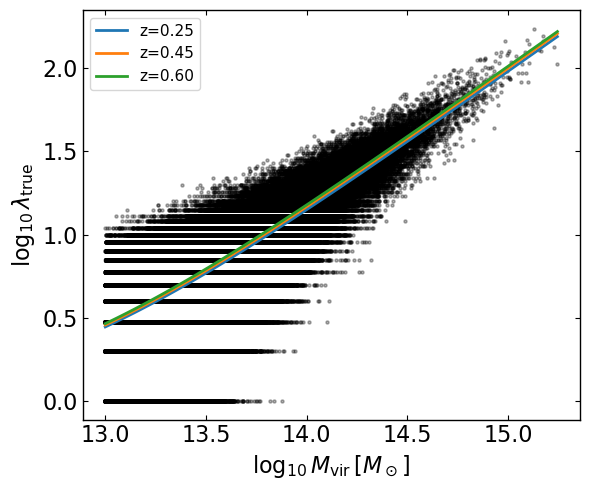

In [36]:
Mvir = np.asarray(mock['Mvir'], dtype=float)
zcl  = np.asarray(mock['redshift'], dtype=float)

lambda_true = sample_lambda_true(Mvir, zcl, rng=RNG).astype(float)
mock['lambda_true'] = lambda_true

print('mean lambda_true:', lambda_true.mean())
print('fraction lambda_true >= 5 :', (lambda_true >= 5).mean())
print('fraction lambda_true >= 20:', (lambda_true >= 20).mean())

# Sanity: expected mean relation vs sampled halos.
logM = np.log10(Mvir)
fig, ax = plt.subplots(figsize=(6, 5))
# ax.hexbin(logM, np.log10(np.clip(lambda_true, 1, None)), gridsize=60,
#           mincnt=1, cmap='Greys')
ax.scatter(logM, np.log10(np.clip(lambda_true, 1, None)), alpha=0.3, s=5, color='k')
mg = np.linspace(logM.min(), logM.max(), 80)
for zref in [0.25, 0.45, 0.60]:
    ax.plot(mg, np.log10(l_tr(10**mg, zref)), lw=2, label='z=%.2f' % zref)
ax.set_xlabel(r'$\log_{10} M_\mathrm{vir}\,[M_\odot]$')
ax.set_ylabel(r'$\log_{10} \lambda_\mathrm{true}$')
ax.legend(fontsize=11); fig.tight_layout()

Show the scatter of the sampled intrinsic richness, $\lambda_{\rm true}$, around the expected mean richness--mass relation:

$$
\log_{10}\left(
\frac{\lambda_{\rm true}}
{\langle \lambda_{\rm true} \mid M, z_{\rm ref} \rangle}
\right).
$$

The distribution is not symmetric in log space, and because the halo catalogue is dominated by low-richness halos so there is tail at lower richness.

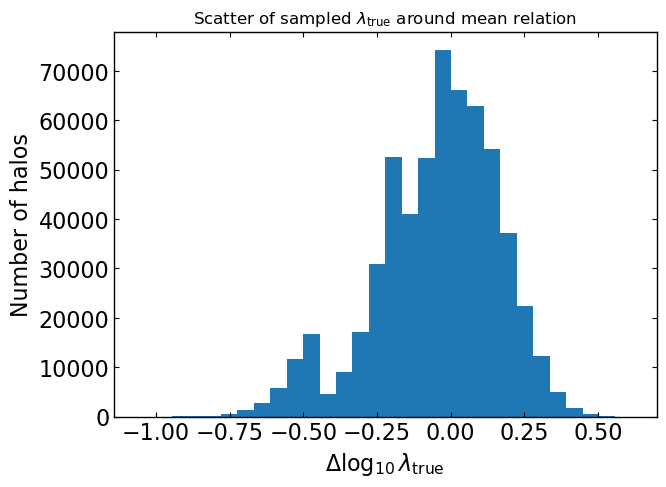

In [37]:
plt.figure(figsize=(7, 5))

# Compare each sampled lambda_true to the mean relation evaluated at that
# halo's own redshift, not at a single reference z.
plt.hist(
    np.log10(np.clip(lambda_true, 1, None)) - np.log10(l_tr(Mvir, zcl)),
    bins=30
)

plt.xlabel(r'$\Delta \log_{10} \lambda_{\rm true}$')
plt.ylabel('Number of halos')
plt.title(r'Scatter of sampled $\lambda_{\rm true}$ around mean relation')

plt.show()

In [38]:
np.log10(l_tr(Mvir, zcl))

array([1.02008459, 0.6307012 , 1.02423139, ..., 0.46835689, 0.52477553,
       0.48750511], shape=(583043,))

## 4. Project $\lambda_\mathrm{true} \to \lambda_\mathrm{obs}$

Costanzi+2019, Eq. 6 ([arXiv:1807.07072](https://arxiv.org/abs/1807.07072)):

$$
P(\lambda_\mathrm{obs}|\lambda_\mathrm{true},z) =
(1 - f_\mathrm{prj})\,\mathcal{N}(\mu,\sigma) +
f_\mathrm{prj}\,\frac{\tau}{2}\,
\exp\!\left[\frac{\tau}{2}(2\mu + \tau\sigma^2 - 2\lambda_\mathrm{obs})\right]\,
\mathrm{erfc}\!\left(\frac{\mu + \tau\sigma^2 - \lambda_\mathrm{obs}}{\sqrt{2}\,\sigma}\right),
$$

with $\mu = \mu(\lambda_\mathrm{true}, z)$ a linear function of $\lambda_\mathrm{true}$,
$\sigma = \sigma(\lambda_\mathrm{true}, z)$ a power law, $f_\mathrm{prj}$ a sigmoid,
and $\tau$ a power law. All four parameters are evaluated from the
SDSS-calibrated posterior-mean coefficients in
`prj_params_DESY3_lss_lin_dep_getdist_v1.txt` via `projection_params`.

The mixture is sampled directly: with probability $1-f_\mathrm{prj}$ we draw
from the Gaussian; with probability $f_\mathrm{prj}$ we draw from the
exponentially-modified Gaussian as `N(mu, sigma) + Exp(1/tau)` (sum of
independent draws — the EMG closed form is the convolution of these two).

In [39]:
# --- Sample lambda_obs from Costanzi+2019 Eq. 6 ---
zcl_for_projection = np.asarray(mock['redshift_obs'], dtype=float)  # was 'redshift'
lambda_obs, f_prj, tau, mu_prj, sig_prj = sample_lambda_obs(
    lambda_true, zcl_for_projection, PRJ_INTERP, rng=RNG)

mock['lambda_obs'] = lambda_obs
mock['f_prj']      = f_prj
mock['tau_prj']    = tau
mock['mu_prj']     = mu_prj
mock['sig_prj']    = sig_prj

assert len(lambda_obs) == len(lambda_true)

dlam = lambda_obs - lambda_true
print('<lambda_true>           = %.3f' % lambda_true.mean())
print('<lambda_obs>            = %.3f' % lambda_obs.mean())
print('<Delta lambda>          = %.3f' % dlam.mean())
print('<f_prj>                 = %.3f' % f_prj.mean())
print('<1/tau>                 = %.3f' % np.mean(1.0 / tau))
print('<sigma>                 = %.3f' % sig_prj.mean())
print('<mu - lambda_true>      = %.3f' % (mu_prj - lambda_true).mean())

<lambda_true>           = 5.498
<lambda_obs>            = 5.497
<Delta lambda>          = -0.000
<f_prj>                 = 0.608
<1/tau>                 = 1.622
<sigma>                 = 2.375
<mu - lambda_true>      = -1.100


/tmp/ipykernel_2293137/4157574052.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


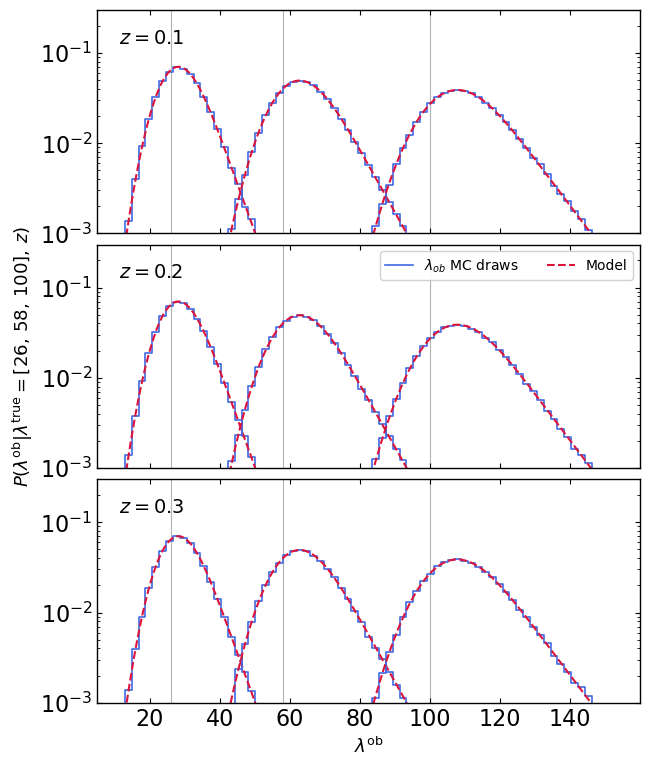

In [40]:
# --- Analytical PDF of Costanzi+2019 Eq. 6 ---------------------------------
def p_lambda_obs(lobs, ltr, z, interp):
    """
    Closed-form P(lambda_obs | lambda_true, z) from Costanzi+2019 Eq. 6.
    Evaluated point-wise: lobs (nr,), ltr scalar, z scalar.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian branch
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG branch — closed form. Compute the log first to avoid overflow in exp.
    a   = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    return (1.0 - f_prj) * gauss + f_prj * emg

# --- Settings ---
LTR_FIX = [26, 58, 100]
Z_FIX   = [0.1, 0.2, 0.3]
N_DRAWS = 200_000
BINS    = np.linspace(5, 160, 80)
BCEN    = 0.5 * (BINS[:-1] + BINS[1:])

# --- Plot ---
fig, axes = plt.subplots(len(Z_FIX), 1, figsize=(7, 9),
                          sharex=True, sharey=True,
                          gridspec_kw={'hspace': 0.05})

rng_plot = np.random.default_rng(seed=123)

for irow, z0 in enumerate(Z_FIX):
    ax = axes[irow]
    for ltr0 in LTR_FIX:
        ltr_arr = np.full(N_DRAWS, ltr0, dtype=float)
        z_arr   = np.full(N_DRAWS, z0,   dtype=float)

        lobs_draw, *_ = sample_lambda_obs(ltr_arr, z_arr, PRJ_INTERP, rng=rng_plot)

        hist, _ = np.histogram(lobs_draw, bins=BINS, density=True)
        ax.step(BCEN, hist, where='mid', color='royalblue', lw=1.2,
                label=(r'$\lambda_{ob}$ MC draws'
                       if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        x = np.linspace(BINS[0], BINS[-1], 600)
        pdf = p_lambda_obs(x, ltr0, z0, PRJ_INTERP)
        ax.plot(x, pdf, '--', color='crimson', lw=1.5,
                label=('Model' if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        ax.axvline(ltr0, color='0.7', lw=0.8, zorder=0)

    ax.set_yscale('log')
    ax.set_ylim(1e-3, 3e-1)
    ax.set_xlim(5, 160)
    ax.text(0.04, 0.85, r'$z = %.1f$' % z0,
            transform=ax.transAxes, fontsize=14)

    if irow == 1:
        ax.legend(loc='upper right', fontsize=10, ncol=2,
                  frameon=True, framealpha=0.9)

# One y-label on the middle row
axes[1].set_ylabel(
    r'$P(\lambda^{\rm ob}|\lambda^{\rm true} = [26,\,58,\,100],\,z)$',
    fontsize=13,
)
axes[-1].set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)

# Linear x-axis ticks
for ax in axes:
    ax.xaxis.set_major_locator(FixedLocator([20, 40, 60, 80, 100, 120, 140]))
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True)

fig.tight_layout()
plt.show()

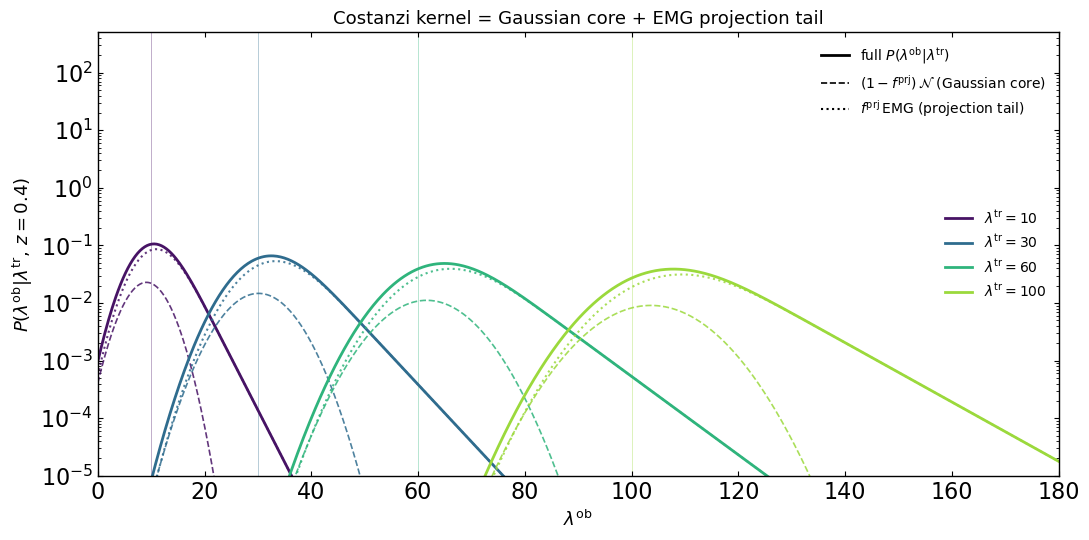

In [41]:
# --- Decomposed PDF: returns (gauss_core, emg_tail, total) at given lobs grid ---
def p_lambda_obs_decomposed(lobs, ltr, z, interp):
    """
    Returns the two components of Costanzi+2019 Eq. 6 separately:

        gauss_core  = (1 - f_prj) * N(mu, sigma)
        emg_tail    = f_prj * EMG(mu, sigma, tau)
        total       = gauss_core + emg_tail

    Each output has the same shape as `lobs`.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian component
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG component — compute log first to avoid overflow in the exponential.
    a = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    gauss_core = (1.0 - f_prj) * gauss
    emg_tail   = f_prj * emg
    total      = gauss_core + emg_tail
    return gauss_core, emg_tail, total


# --- Plot ---
LTR_LIST = [10, 30, 60, 100]
Z_FIX    = 0.4

# Viridis-like color sequence matching the reference plot
cmap = plt.get_cmap('viridis')
colors = [cmap(0.05), cmap(0.35), cmap(0.65), cmap(0.85)]

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.linspace(0.01, 180, 800)

for ltr0, c in zip(LTR_LIST, colors):
    gauss_core, emg_tail, total = p_lambda_obs_decomposed(x, ltr0, Z_FIX, PRJ_INTERP)

    ax.plot(x, total,      '-',  lw=2.0, color=c, label=r'$\lambda^{\rm tr}=%i$' % ltr0)
    ax.plot(x, gauss_core, '--', lw=1.2, color=c, alpha=0.85)
    ax.plot(x, emg_tail,   ':',  lw=1.5, color=c, alpha=0.85)

    ax.axvline(ltr0, color=c, lw=0.6, alpha=0.4, zorder=0)

ax.set_yscale('log')
ax.set_xlim(0, 180)
ax.set_ylim(1e-5, 5e2)
ax.set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)
ax.set_ylabel(r'$P(\lambda^{\rm ob}|\lambda^{\rm tr},\,z=%.1f)$' % Z_FIX, fontsize=13)
ax.set_title('Costanzi kernel = Gaussian core + EMG projection tail', fontsize=13)

# Two legends: one for the component linestyles (top right area),
# one for the lambda_true colors (mid right). Use proxy artists so
# the linestyle legend isn't tied to a specific color.
from matplotlib.lines import Line2D
style_handles = [
    Line2D([], [], color='k', ls='-',  lw=2.0, label=r'full $P(\lambda^{\rm ob}|\lambda^{\rm tr})$'),
    Line2D([], [], color='k', ls='--', lw=1.2, label=r'$(1-f^{\rm prj})\,\mathcal{N}$ (Gaussian core)'),
    Line2D([], [], color='k', ls=':',  lw=1.5, label=r'$f^{\rm prj}\,$EMG (projection tail)'),
]
leg_style = ax.legend(handles=style_handles, loc='upper right',
                       fontsize=10, frameon=False)
ax.add_artist(leg_style)
ax.legend(loc='center right', fontsize=10, frameon=False, title=None)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
fig.tight_layout()
plt.show()

## 5. Output 1 — $N(\lambda_\mathrm{obs}, z)$

In [42]:
def compute_number_counts(x, z, xbins, zmin_list, zmax_list):
    counts = []
    for xl, xh in zip(xbins[:-1], xbins[1:]):
        xmask = (x >= xl) & (x < xh)
        row = []
        for zl, zh in zip(zmin_list, zmax_list):
            row.append(int(np.count_nonzero(xmask & (z >= zl) & (z < zh))))
        counts.append(row)
    return np.array(counts)

# Bin on the observed (photo-z) redshift to be consistent with the
# observed-frame projection used to draw lambda_obs.
nc_obs = compute_number_counts(np.asarray(mock['lambda_obs']),
                                np.asarray(mock['redshift_obs']),
                                LBDBINS, ZMIN_LIST, ZMAX_LIST)
print('N(lambda_obs, z_obs):')
print(nc_obs)

N(lambda_obs, z_obs):
[[28903 71482 90166]
 [ 4138  9419 11699]
 [ 1242  2739  3120]
 [  482   941   903]]


## 6. Stacked $\Sigma(R)$ in $\lambda$ bins: true vs observed

The lensing data vector is built by **stacking** — averaging $\Sigma(R)$ over halos in each $(\lambda, z)$ bin:

$$
\langle\Sigma(R) \mid \lambda \in [\lambda_1, \lambda_2),\, z \in [z_1, z_2)\rangle
= \frac{1}{N_\mathrm{bin}}\sum_{i \in \mathrm{bin}} \Sigma_i(R).
$$

Each halo's $\Sigma_i(R)$ is set by its mass via the NFW-like projected profile, so the stacked profile is shaped by the **mass distribution within the bin**.

Comparing two stacks at the same numerical $\lambda$ — one binned on $\lambda^\mathrm{tr}$, one on $\lambda^\mathrm{ob}$ — reveals how optical selection alters that mass distribution:

- The $\lambda^\mathrm{tr}$ bin contains halos whose intrinsic richness lies in the range, so it samples a narrow mass range set by the Costanzi mass-richness relation.
- The $\lambda^\mathrm{ob}$ bin additionally sweeps in low-mass halos that got projection-boosted up into the range via the asymmetric Costanzi+2019 Eq. 6 kernel.

So $\langle\Sigma|\lambda^\mathrm{ob}\rangle < \langle\Sigma|\lambda^\mathrm{tr}\rangle$ is expected: the $\lambda^\mathrm{ob}$ bin pulls in extra low-mass halos via the projection tail, dragging the mean mass — and hence the mean $\Sigma$ — below the $\lambda^\mathrm{tr}$ stack. This is the **mass-dilution** (Eddington-like) piece of the optical-selection effect that the forward model captures.

Halos per (lambda_true bin, z bin):
[[ 34093  84812 107207]
 [  2910   6426   7720]
 [   861   1822   2023]
 [   317    559    513]]
Halos per (lambda_obs bin, z bin):
[[28903 71482 90166]
 [ 4138  9419 11699]
 [ 1242  2739  3120]
 [  482   941   903]]


/tmp/ipykernel_2293137/661141296.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


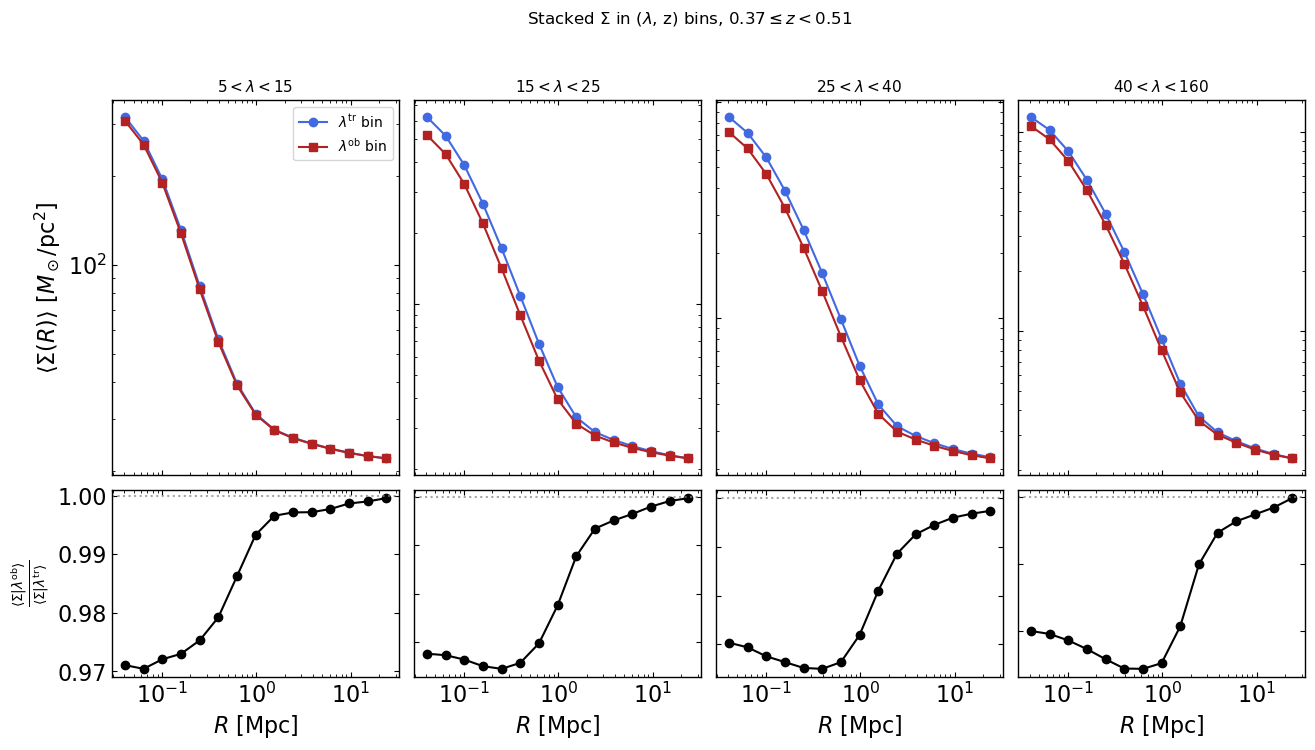

In [43]:
# --- Inputs ----------------------------------------------------------------
ltr_arr     = np.asarray(mock['lambda_true'])
lob_arr     = np.asarray(mock['lambda_obs'])
zcl_arr     = np.asarray(mock['redshift_obs'])     # bin on observed z (photo-z)
Sigma_arr   = np.asarray(mock['Sigma'])            # (nh, nr)
radii_arr   = np.asarray(rbp.rp_phys_mpc)          # (nr,)

# --- Stack Sigma in (lambda, z) bins ---------------------------------------
def stack_sigma(lam, z, Sigma, lam_bins, z_min_list, z_max_list):
    """
    Returns mean Sigma profile per (lam_bin, z_bin), shape (nl, nz, nr),
    plus halo counts per bin, shape (nl, nz).
    """
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = Sigma.shape[1]
    mean_Sigma = np.zeros((nl, nz, nr))
    counts     = np.zeros((nl, nz), dtype=int)

    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            n = int(m.sum())
            counts[il, iz] = n
            if n > 0:
                mean_Sigma[il, iz] = Sigma[m].mean(axis=0)
    return mean_Sigma, counts


Sigma_ltr, N_ltr = stack_sigma(ltr_arr, zcl_arr, Sigma_arr, LBDBINS, ZMIN_LIST, ZMAX_LIST)
Sigma_lob, N_lob = stack_sigma(lob_arr, zcl_arr, Sigma_arr, LBDBINS, ZMIN_LIST, ZMAX_LIST)

print("Halos per (lambda_true bin, z bin):")
print(N_ltr)
print("Halos per (lambda_obs bin, z bin):")
print(N_lob)

# --- Plot ------------------------------------------------------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)
zb = 1   # which redshift bin to show; change to taste

fig, axes = plt.subplots(2, nl, figsize=(nl * 3.6 + 1, 7.5),
                          sharex=True,
                          gridspec_kw={'hspace': 0.05, 'wspace': 0.05,
                                       'height_ratios': [3, 1.5]})

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_tr = Sigma_ltr[il, zb]
    s_ob = Sigma_lob[il, zb]

    # Top: stacked Sigma profiles
    ax_top.loglog(radii_arr, s_tr, 'o-', color='royalblue',  label=r'$\lambda^{\rm tr}$ bin')
    ax_top.loglog(radii_arr, s_ob, 's-', color='firebrick',  label=r'$\lambda^{\rm ob}$ bin')
    ax_top.set_title(r'$%i < \lambda < %i$' % (LBDBINS[il], LBDBINS[il + 1]),
                     fontsize=11)

    # Bottom: ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(s_tr > 0, s_ob / s_tr, np.nan)
    ax_bot.semilogx(radii_arr, ratio, 'o-', color='black')
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)

    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$\langle\Sigma(R)\rangle\ [M_\odot/{\rm pc}^2]$')
axes[1, 0].set_ylabel(
    r'$\frac{\langle\Sigma | \lambda^{\rm ob}\rangle}{\langle\Sigma | \lambda^{\rm tr}\rangle}$',
    fontsize=14,
)
axes[0, 0].legend(loc='upper right', fontsize=10)

fig.suptitle(r'Stacked $\Sigma$ in ($\lambda$, z) bins, '
             r'$%.2f \leq z < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
             y=1.00, fontsize=12)
fig.tight_layout()
plt.show()

## 7. Shear data vector with the full projection effect

Forward-model the lensing data vector by converting per-halo $\Sigma$ to per-halo
$\gamma_t$, stacking on $\lambda^\mathrm{ob}$, then injecting the analytical
$\mathcal{B}_\mathrm{sel}(R)$:

$$
\langle\gamma_t(R) \mid \lambda^\mathrm{ob}, z\rangle_\mathrm{model}
= \mathcal{B}_\mathrm{sel}(R; \lambda^\mathrm{ob}, z)
  \cdot \langle\Delta\Sigma(R) \cdot \Sigma_\mathrm{crit}^{-1}(z) \mid \lambda^\mathrm{ob}, z\rangle.
$$

The first factor injects the **environment-correlated** projection bias from
Costanzi+2026 Appendix C, Eq. C1 ([arXiv:2604.05833](https://arxiv.org/abs/2604.05833)),
a double power-law with smooth transition:

$$
\mathcal{B}_\mathrm{sel}(R) =
A\,\left(\frac{R}{R_0}\right)^{\alpha}\,
\left[\,1 + \left(\frac{R}{R_0}\right)^{\gamma}\,\right]^{(\beta-\alpha)/\gamma}
+ 1,
$$

with the global Buzzard best-fit constants
$(A,\alpha,\beta,\gamma) = (0.10,\,0.92,\,-0.53,\,4.1)$ and the
transition scale set to the comoving cluster radius
$R_0 = R_\lambda(1+z)$ where $R_\lambda = (\lambda_\mathrm{ob}/100)^{0.2}\,h^{-1}\,\mathrm{Mpc}$
(C26 Appendix B). Inside the function, $R$ is converted from physical Mpc to
comoving $\mathrm{Mpc}/h$ before evaluating the ratio $R/R_0$.

The second factor is the stacked shear from the forward model, which already
carries the **mass-dilution** piece of the projection effect from binning on
$\lambda^\mathrm{ob}$ (Section 6).

$\Delta\Sigma$ is taken from the catalog field `mock['DeltaSigma']` (computed via
particle-pair counting, which automatically handles the LSS background and
small-scale resolution issues that the integrate-Σ route inherits).

In [44]:
radii = rbp.rp_phys_mpc # physical Mpc (no h)
lambda_obs_sel = np.asarray(mock['lambda_obs'])
# ------------------------------------------------------------
# 1. Lensing geometry: Sigma_crit^{-1}
# ------------------------------------------------------------
bTable  = np.load(floc.mock_boost_factor_1d) # beta = D_ls / D_s for each lens z and source z bin.
betaEff = bTable['betaEff']; zlens = bTable['zlens']

const = 6.01e-19 * 1e6           # pc / Msun (4 pi G / c^2)
dlens = cosmo0.comoving_distance(zlens).value * 1e6   # pc
sigma_crit_inv_vec = const * dlens[:, np.newaxis] * betaEff
sigma_crit_inv_vec_z = sigma_crit_inv_vec[:, -1]

# ------------------------------------------------------------
# 2. Load halo redshift and Sigma(R)
# -----------------------------------------------------------
# Sigma_crit^{-1} is a measurement-side quantity: it depends on the
# photo-z we would assign to the lens, not on the true z.
redshift_sel = np.asarray(mock['redshift_obs'])
Sigma   = np.asarray(mock['Sigma'])
# One Sigma_crit^{-1} value per halo
sigma_crit_inv = np.interp(redshift_sel, zlens, sigma_crit_inv_vec_z)
DeltaSigma = np.asarray(mock['DeltaSigma'])
shear      = DeltaSigma * sigma_crit_inv[:, np.newaxis]

In [45]:
# Step 1: stack the per-halo shear on (lambda_obs, z_obs) bins.
# Plain mean, no mass-matching.
def stack_shear(lam, z, shear, lam_bins, z_min_list, z_max_list):
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = shear.shape[1]
    stacked = np.zeros((nl, nz, nr))
    counts  = np.zeros((nl, nz), dtype=int)
    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            counts[il, iz] = m.sum()
            if m.any():
                stacked[il, iz] = shear[m].mean(axis=0)
    return stacked, counts


# Costanzi+2026 Appendix C, Eq. C1 (arXiv:2604.05833, p. 12)
# Constants from the global fit to the full Buzzard catalog:
A_C1, ALPHA_C1, BETA_C1, GAMMA_C1 = 0.10, 0.92, -0.53, 4.1


def Bsel_C1(R_phys_mpc, lambda_rep, z_rep,
            A=A_C1, alpha=ALPHA_C1, beta=BETA_C1, gamma=GAMMA_C1,
            h=None):
    """
    Costanzi+2026 Appendix C Eq. C1 (arXiv:2604.05833, p. 12).

    The analytical optical-selection bias on the lensing profile:

        B_sel(R) = A (R/R_0)^alpha * [1 + (R/R_0)^gamma]^((beta-alpha)/gamma) + 1

    The calibration was performed in comoving Mpc/h, so:
        R_0      = (lambda/100)^0.2 * (1+z)   [comoving Mpc/h]   (App. B)
        R        is converted from physical Mpc to comoving Mpc/h internally.

    Parameters
    ----------
    R_phys_mpc : (nr,)
        Radii in PHYSICAL Mpc (the `rp_phys_mpc` convention).
    lambda_rep : scalar
        Representative observed richness for the bin.
    z_rep : scalar
        Representative redshift for the bin.
    A, alpha, beta, gamma : floats
        Costanzi+2026 best-fit constants from the global fit.
    h : float or None
        Little-h. If None, taken from cosmo0.h (assumes cosmo0 is in scope).

    Returns
    -------
    B_sel : (nr,)
        Multiplicative B_sel(R), values around 1.0 with a ~1.05-1.15 peak
        near R ~ 1 Mpc/h.
    """
    if h is None:
        h = cosmo0.h   # uses the FlatLambdaCDM cosmo0 from Section 1

    R_phys_mpc = np.asarray(R_phys_mpc, dtype=float)

    # Convert R from physical Mpc to comoving Mpc/h
    R_cMpc_h = R_phys_mpc * (1.0 + z_rep) * h

    # Transition scale R_0 in comoving Mpc/h
    R_lambda_hinvMpc = (lambda_rep / 100.0) ** 0.2          # h^-1 Mpc, App. B
    R0 = R_lambda_hinvMpc * (1.0 + z_rep)                    # comoving Mpc/h

    x = R_cMpc_h / R0
    return A * x ** alpha * (1.0 + x ** gamma) ** ((beta - alpha) / gamma) + 1.0


# Step 2: multiply on B_sel(R) per bin using the published formula.
lam_bin_arr = np.asarray(mock['lambda_obs'])
z_bin_arr   = np.asarray(mock['redshift_obs'])

shear_stacked, N_sel = stack_shear(
    lam_bin_arr, z_bin_arr, shear,
    LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

B_sel = np.zeros_like(shear_stacked)
for il in range(len(LBDBINS) - 1):
    in_lam = (lam_bin_arr >= LBDBINS[il]) & (lam_bin_arr < LBDBINS[il + 1])
    for iz in range(len(ZMIN_LIST)):
        in_z = (z_bin_arr >= ZMIN_LIST[iz]) & (z_bin_arr < ZMAX_LIST[iz])
        m = in_lam & in_z
        if m.any():
            B_sel[il, iz] = Bsel_C1(
                radii,
                float(np.mean(lam_bin_arr[m])),
                float(np.mean(z_bin_arr[m])),
            )

shear_data_vector = shear_stacked * B_sel

print("B_sel at R=0.04, 1.0, 10.0 Mpc for lambda=30, z=0.3:")
print(Bsel_C1(np.array([0.04, 1.0, 10.0]), 30.0, 0.3))

B_sel at R=0.04, 1.0, 10.0 Mpc for lambda=30, z=0.3:
[1.00465152 1.07575843 1.03138002]


/tmp/ipykernel_2293137/2017976305.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


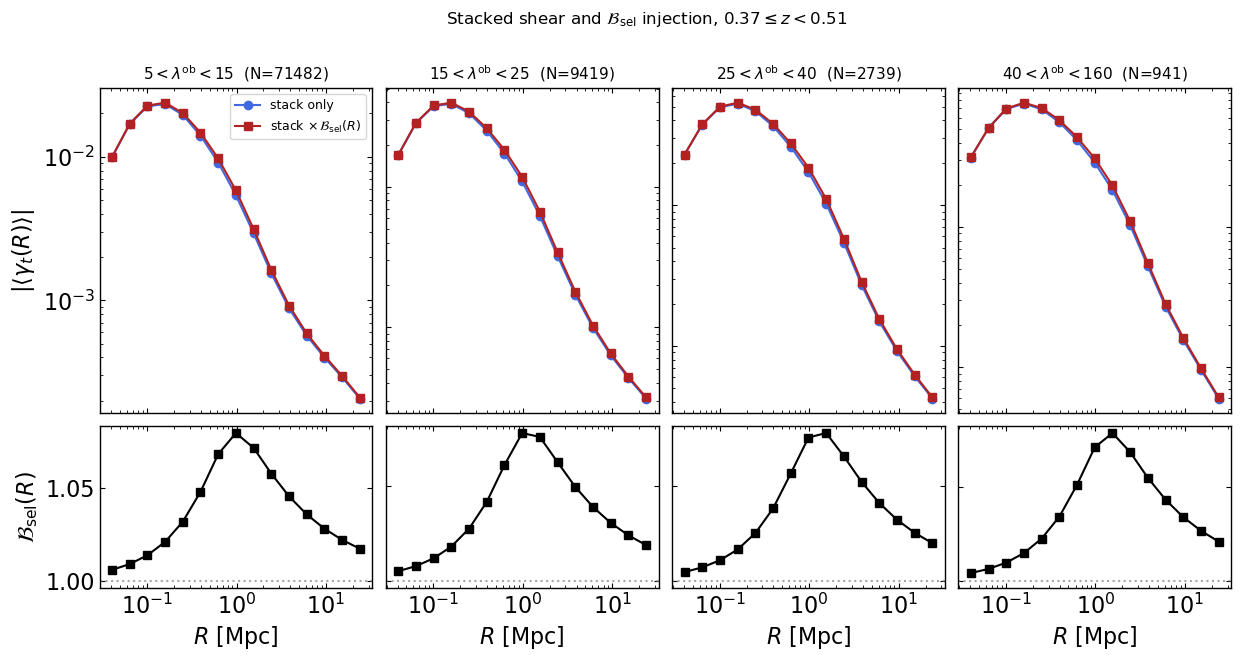

In [46]:
# --- Plot: stacked shear per (lambda_obs, z) bin, with and without B_sel ---

nl = len(LBDBINS) - 1
zb = 1   # pick a redshift bin to display; change to 0 or 2 to see others

fig, axes = plt.subplots(
    2, nl, figsize=(nl * 3.4 + 1, 6.5),
    sharex=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05, 'height_ratios': [3, 1.5]},
)

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_stack = shear_stacked[il, zb]
    s_final = shear_data_vector[il, zb]
    B_R     = B_sel[il, zb]

    # Top panel: stacked shear, with and without B_sel
    ax_top.loglog(radii, np.abs(s_stack), 'o-', color='royalblue',
                   label=r'stack only')
    ax_top.loglog(radii, np.abs(s_final), 's-', color='firebrick',
                   label=r'stack $\times\,\mathcal{B}_{\rm sel}(R)$')

    ax_top.set_title(
        r'$%i < \lambda^{\rm ob} < %i$  (N=%d)' %
        (LBDBINS[il], LBDBINS[il + 1], N_sel[il, zb]),
        fontsize=11,
    )

    # Bottom panel: B_sel(R) for this bin
    ax_bot.semilogx(radii, B_R, 's-', color='black')
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)
    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$|\langle\gamma_t(R)\rangle|$')
axes[1, 0].set_ylabel(r'$\mathcal{B}_{\rm sel}(R)$')
axes[0, 0].legend(loc='upper right', fontsize=9)

fig.suptitle(
    r'Stacked shear and $\mathcal{B}_{\rm sel}$ injection, '
    r'$%.2f \leq z < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
    y=1.00, fontsize=12,
)
fig.tight_layout()
plt.show()

## 8. Save the data vector

Persist the number counts $N(\lambda^\mathrm{ob}, z^\mathrm{ob})$ and the
$\mathcal{B}_\mathrm{sel}$-corrected stacked shear vector
$\langle\gamma_t(R)\rangle$ to `/global/u2/x/xintang/mocks/data/` as a single
`.npz` archive so downstream analyses can consume it without re-running the
forward model.

In [ ]:
out_dir = '/global/u2/x/xintang/mocks/data'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'Xin_MockDataVector.npz')

np.savez(
    out_path,
    radii_phys_mpc=np.asarray(radii),
    lambda_bins=np.asarray(LBDBINS),
    z_bin_min=np.asarray(ZMIN_LIST),
    z_bin_max=np.asarray(ZMAX_LIST),
    number_counts=nc_obs,                    # (n_lam, n_z)
    shear_stacked=shear_stacked,             # (n_lam, n_z, n_r), no Bsel
    B_sel=B_sel,                             # (n_lam, n_z, n_r)
    shear_data_vector=shear_data_vector,     # (n_lam, n_z, n_r), with Bsel
    counts_per_bin=N_sel,                    # (n_lam, n_z)
)

print('Saved data vector to: %s' % out_path)


Saved data vector to: /global/u2/x/xintang/mocks/mock/Xin_MockDataVector.npz
